In [22]:
from resources.imports import *

import torch
import torch.nn as nn

from resources.MLdata import DATA
from resources.MLfunc import EarlyStopping, CombinedCurveLoss, QuantileLoss, QuantileLossMATLAB
from resources.MLfunc import hOpt_model, hOpt_compare, hOpt_best_summary
from resources.MLmodels import *

In [2]:
%load_ext autoreload
%autoreload 2

# Stress-Strain Curve

## Multi-Layer Perceptrion (MLP)

In [ ]:
DAT_MLP = DATA(
    path=1, 
    path_add="",
    load=True, 
    load_split=False,
    split_frac=0.9,
    split_seed=42,
    range_split=(True, False),
    save_split=False,
    LAT="FCC", 
    dis="disNodes", 
    dN=0.2,
    d_data="in",
    mechMode="UT",
    nsims=None,
    model="MLP",
    scale=("symm", "inout"),
    reduce_dim=False, #("PCA", "out", 0.95, 10, True)
    round_decimals=5
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
DAT = DAT_MLP
if DAT.UTmechTest:
    print("UT shape:", DAT.UT_train_in.shape, DAT.UT_train_out.shape)
    print("Train -  in (min, max):", DAT.UT_train_in.min(), DAT.UT_train_in.max(), "\n        out (min, max):", DAT.UT_train_out.min(), DAT.UT_train_out.max())
    print("  Val -  in (min, max):", DAT.UT_val_in.min(), DAT.UT_val_in.max(), "\n        out (min, max):", DAT.UT_val_out.min(), DAT.UT_val_out.max())
    print(" Test -  in (min, max):", DAT.UT_test_in.min(), DAT.UT_test_in.max(), "\n        out (min, max):", DAT.UT_test_out.min(), DAT.UT_test_out.max())
    if DAT.FTmechTest: print("\n========================================================\n")
if DAT.FTmechTest:
    print("FT shape:", DAT.FT_train_in.shape, DAT.FT_train_out.shape)
    print("Train -  in (min, max):", DAT.FT_train_in.min(), DAT.FT_train_in.max(), "\n        out (min, max):", DAT.FT_train_out.min(), DAT.FT_train_out.max())
    print("  Val -  in (min, max):", DAT.FT_val_in.min(), DAT.FT_val_in.max(), "\n        out (min, max):", DAT.FT_val_out.min(), DAT.FT_val_out.max())
    print(" Test -  in (min, max):", DAT.FT_test_in.min(), DAT.FT_test_in.max(), "\n        out (min, max):", DAT.FT_test_out.min(), DAT.FT_test_out.max())

UT shape: (5561, 1444) (5561, 201)
Train -  in (min, max): -1.0 1.0 
        out (min, max): 0.0 63.50968603027344
  Val -  in (min, max): -0.9999973122467288 0.9999986561115777 
        out (min, max): 0.0 61.962560776367184
 Test -  in (min, max): -1.0 1.0 
        out (min, max): 0.0 61.98362002441407


In [5]:
# HYPERPARAMETER OPTIMIZATION HERE.
# Full HPO run on the full DATA split. Re-running resumes the saved Optuna study.

MLP_hOpt_model_space = {
    "depth": [2, 3, 4, 5],
    "width": [128, 256, 512],
    "block": ["mlp", "res"],
    "act": ["relu", "gelu", "mish"],
    "norm": [None, "batch", "layer"],
    "dropout": {"type": "float", "low": 0.0, "high": 0.25},
    "head_norm": [None, "layer"],
    "head_dropout": {"type": "float", "low": 0.0, "high": 0.20},
}

MLP_hOpt_loss_space = {
    "family": ["mse", "combined"],
    "mse_weight": [0.25, 0.5, 1.0],
    "weighted_mse_weight": [0.0, 0.5, 1.0, 2.0],
    "derivative_weight": [0.0, 0.02, 0.05, 0.10],
    "peak_weight": [0.0, 0.10, 0.25, 0.50],
    "energy_weight": [0.0, 0.05, 0.10, 0.25],
    "peak_location_weight": [0.0, 0.02, 0.05],
    "reduction": ["mean"],
    "derivative_order": [1],
    "SoftPeak_beta": [10.0, 20.0, 40.0],
    "UT": {
        "zone_boundaries": (67, 134),
        "zone_weights": (1.0, 5.0, 2.0),
    },
}

MLP_hOpt_train_space = {
    "optimizer": ["adamw"],
    "lr": {"type": "float", "low": 5e-5, "high": 2e-3, "log": True},
    "weight_decay": {"type": "float", "low": 1e-8, "high": 1e-3, "log": True},
    "batch": [16, 32, 64],
    "n_epochs": {"type": "fixed", "value": 250},
    "metric": ["rmse"],
    "scheduler": ["plateau"],
    "scheduler_factor": [0.3, 0.5],
    "scheduler_patience": [10, 20],
    "scheduler_threshold": {"type": "fixed", "value": 1e-4},
    "early_stop": [True],
    "early_stop_patience": [30, 50],
    "early_stop_min_delta": {"type": "fixed", "value": 1e-5},
    "verbose": {"type": "fixed", "value": 0},
}

study_MLP_full = hOpt_model(
    typ="mlp",
    data=DAT_MLP,
    n_trials=50,
    model_space=MLP_hOpt_model_space,
    loss_space=MLP_hOpt_loss_space,
    train_space=MLP_hOpt_train_space,
    seed=42,
    device=device,
    save=True,
    name="MLP_full_hOpt",
    n_jobs=1,
    show_progress_bar=True,
)

hOpt_best_summary(study_MLP_full)

c:\Programs\Python39\lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Programs\Python39\lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
C:\Users\exy053\Documents\00-PhD-gitRepo\resources\MLfunc.py:1662: ExperimentalWarning: PatientPruner is experimental (supported from v2.8.0). The interface can change in the future.
  pruner = optuna.pruners.PatientPruner(base_pruner, patience=5) if hasattr(optuna.pruners, "PatientPruner") else base_pruner
[I 2026-05-06 19:31:13,018] A new study created in RDB with name: MLP_smoke_hOpt


 -> Epoch 1/2 || LOSS - train: 1052.757695, val: 917.531266 | MSE - train: 1052.757695, val: 917.531266 | RMSE - train: 32.446228, val: 30.290779 | LR: 9.33e-04


[I 2026-05-06 19:31:14,107] Trial 0 finished with value: 22.26936735781222 and parameters: {'mlp_act': 'gelu', 'mlp_norm': None, 'mlp_dropout': 0.015601864044243652, 'mlp_depth': 1, 'mlp_width': 64, 'mlp_block': 'mlp', 'mlp_head_norm': None, 'loss_family': 'mse', 'optimizer': 'adamw', 'lr': 0.0009330606024425672, 'weight_decay': 2.1368329072358724e-05, 'batch': 32, 'objective_metric': 'rmse', 'w_init': 'auto', 'scheduler': 'none', 'early_stop': False}. Best is trial 0 with value: 22.26936735781222.


 -> Epoch 2/2 || LOSS - train: 603.070866, val: 495.924723 | MSE - train: 603.070866, val: 495.924723 | RMSE - train: 24.557501, val: 22.269367 | LR: 9.33e-04
================ Training Complete ================
 Best Epoch: 2, with LOSS: 495.924723, MSE: 495.924723 and RMSE: 22.269367 ==================
 -> Epoch 1/2 || LOSS - train: 1138.645325, val: 1125.236097 | MSE - train: 1138.645325, val: 1125.236097 | RMSE - train: 33.743819, val: 33.544539 | LR: 2.86e-04


[I 2026-05-06 19:31:15,244] Trial 1 finished with value: 31.754348976894285 and parameters: {'mlp_act': 'relu', 'mlp_norm': 'batch', 'mlp_dropout': 0.052475643163223784, 'mlp_depth': 1, 'mlp_width': 64, 'mlp_block': 'mlp', 'mlp_head_norm': 'layer', 'loss_family': 'mse', 'optimizer': 'adamw', 'lr': 0.0002858051065806936, 'weight_decay': 1.3826232179369868e-05, 'batch': 32, 'objective_metric': 'rmse', 'w_init': 'auto', 'scheduler': 'none', 'early_stop': False}. Best is trial 0 with value: 22.26936735781222.


 -> Epoch 2/2 || LOSS - train: 1068.664387, val: 1008.338679 | MSE - train: 1068.664387, val: 1008.338679 | RMSE - train: 32.690433, val: 31.754349 | LR: 2.86e-04
================ Training Complete ================
 Best Epoch: 2, with LOSS: 1008.338679, MSE: 1008.338679 and RMSE: 31.754349 ==================

 Optimization Finished. Study statistics: 
  Number of finished trials: 2

Best trial 
 Loss: 22.26936735781222

 Hyperparameters:
  mlp_act: gelu
  mlp_norm: None
  mlp_dropout: 0.015601864044243652
  mlp_depth: 1
  mlp_width: 64
  mlp_block: mlp
  mlp_head_norm: None
  loss_family: mse
  optimizer: adamw
  lr: 0.0009330606024425672
  weight_decay: 2.1368329072358724e-05
  batch: 32
  objective_metric: rmse
  w_init: auto
  scheduler: none
  early_stop: False


{'best_value': 22.26936735781222,
 'best_params': {'mlp_act': 'gelu',
  'mlp_norm': None,
  'mlp_dropout': 0.015601864044243652,
  'mlp_depth': 1,
  'mlp_width': 64,
  'mlp_block': 'mlp',
  'mlp_head_norm': None,
  'loss_family': 'mse',
  'optimizer': 'adamw',
  'lr': 0.0009330606024425672,
  'weight_decay': 2.1368329072358724e-05,
  'batch': 32,
  'objective_metric': 'rmse',
  'w_init': 'auto',
  'scheduler': 'none',
  'early_stop': False},
 'best_user_attrs': {'loss_params': {'family': 'mse'},
  'model_params': {'in_size': 1444,
   'out_size': 201,
   'h_size': [64],
   'act': 'gelu',
   'block': 'mlp',
   'norm': None,
   'dropout': 0.015601864044243652,
   'head_norm': None,
   'head_dropout': 0.0},
  'task_scores': [22.26936735781222],
  'train_params': {'lr': 0.0009330606024425672,
   'weight_decay': 2.1368329072358724e-05,
   'opt_name': 'adamw',
   'batch': 32,
   'n_epochs': 2,
   'verbose': 1,
   'metric': 'rmse',
   'w_init': 'auto',
   'scheduler': None},
  'typ': 'mlp'}}

In [6]:
MLP1 = MODEL(
    typ=DAT.model,
    model=MLP(in_size=DAT.UT_train_in.shape[-1], 
              h_size=[4096, 2048, 1024, 1024, 1024, 512, 512], 
              out_size=DAT.UT_train_out.shape[-1], 
              act="relu",
              block="mlp",
              norm="batch", 
              dropout=0.0).to(device), 
    lossf=QuantileLossMATLAB(quantiles=[0.5, 0.45, 0.1], zone_boundaries=(67, 134), err_type="L2"), #nn.MSELoss(reduction="mean"), #CustomQuantileLoss(quantiles=[0.5, 0.45, 0.1], zone_boundaries=(50, 150), err_type="L2"),
    opt=("adam", 6.016e-6), #("adam", 1e-4),
    batch=32,
    lr=9e-4,
    data=DAT,
    mechMode=DAT.mechMode,
    scheduler=("min", 0.2427, 100, 1e-4), #("min", 0.2427, 18, 1e-4), 
    earlyStop=EarlyStopping(patience=500, min_delta=1e-4, verbose=True),
    w_init="auto",
    device=device,
    optTrial=None,
    scan_matches_on_init=True
)

MLP1.summary()

[MODEL scan] strict matches: 0
[MODEL scan] coarse-only matches: 0


Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [32, 201]                 --
├─Linear: 1-1                            [32, 4096]                5,918,720
├─BatchNorm1d: 1-2                       [32, 4096]                8,192
├─ReLU: 1-3                              [32, 4096]                --
├─ModuleList: 1-4                        --                        --
│    └─mlpBlock: 2-1                     [32, 2048]                --
│    │    └─Linear: 3-1                  [32, 2048]                8,390,656
│    │    └─BatchNorm1d: 3-2             [32, 2048]                4,096
│    │    └─ReLU: 3-3                    [32, 2048]                --
│    └─mlpBlock: 2-2                     [32, 1024]                --
│    │    └─Linear: 3-4                  [32, 1024]                2,098,176
│    │    └─BatchNorm1d: 3-5             [32, 1024]                2,048
│    │    └─ReLU: 3-6                    [32, 1024]    

In [ ]:
MLP1.train(n_epochs=1000, verbose=20, plot=True)    

In [7]:
MLP1.save(path=None, name=None)

'models\\ut\\FCC_disNodes_dN-0.2_data-in_nSims-all_split-frac-0.9-seed-None-range-inTrue-outFalse_round-None_scale-symm-in-cfgHashd111ff_rDim-None\\mlp\\date-20260506-193115_opt-Adam_lr-00009_batch-32_wd-0000006016_loss-QuantileLossMATLAB_earlyStop-patience500_wInit-Auto_sch-min-02427-100-00001_setupHash-4249be6e.mdl'

In [ ]:
MLP1.predict(test_dataloader=None, plot=True)

In [ ]:
for i in range(len(MLP1.UT_test_outputs)):
    plot_predictions(DAT.UT_OUT_df, MLP1.UT_test_outputs, MLP1.UT_truth, indx=i, d_out=False)

## Transformer

In [ ]:
DAT_TR = DATA(
    path=1, 
    path_add="",
    load=True, 
    load_split=False,
    split_frac=0.9,
    split_seed=42,
    range_split=(True, False),
    save_split=False,
    LAT="FCC", 
    dis="disNodes", 
    dN=0.2,
    d_data="in",
    mechMode="UT",
    nsims=None,
    model="TR",
    scale=("symm", "inout"),
    reduce_dim=False, #("PCA", "out", 0.95, 10, True)
    round_decimals=5,
    tr_params={"geom_feats": True, "coord_norm": True}
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [9]:
DAT = DAT_TR
if DAT.UTmechTest:
    print("UT shape:", DAT.UT_train_in.shape, DAT.UT_train_out.shape)
    print("Train -  in (min, max):", DAT.UT_train_in.min(), DAT.UT_train_in.max(), "\n        out (min, max):", DAT.UT_train_out.min(), DAT.UT_train_out.max())
    print("  Val -  in (min, max):", DAT.UT_val_in.min(), DAT.UT_val_in.max(), "\n        out (min, max):", DAT.UT_val_out.min(), DAT.UT_val_out.max())
    print(" Test -  in (min, max):", DAT.UT_test_in.min(), DAT.UT_test_in.max(), "\n        out (min, max):", DAT.UT_test_out.min(), DAT.UT_test_out.max())
    if DAT.FTmechTest: print("\n========================================================\n")
if DAT.FTmechTest:
    print("FT shape:", DAT.FT_train_in.shape, DAT.FT_train_out.shape)
    print("Train -  in (min, max):", DAT.FT_train_in.min(), DAT.FT_train_in.max(), "\n        out (min, max):", DAT.FT_train_out.min(), DAT.FT_train_out.max())
    print("  Val -  in (min, max):", DAT.FT_val_in.min(), DAT.FT_val_in.max(), "\n        out (min, max):", DAT.FT_val_out.min(), DAT.FT_val_out.max())
    print(" Test -  in (min, max):", DAT.FT_test_in.min(), DAT.FT_test_in.max(), "\n        out (min, max):", DAT.FT_test_out.min(), DAT.FT_test_out.max())

UT shape: (953, 800, 8) (953, 201)
Train -  in (min, max): -1.0 1.0 
        out (min, max): -1.0 1.0
  Val -  in (min, max): -1.0 1.0 
        out (min, max): -1.1964692047148027 0.9862895398366256
 Test -  in (min, max): -1.0 1.0 
        out (min, max): -1.0 0.8444540390023729


In [15]:
# HYPERPARAMETER OPTIMIZATION HERE.
# Full HPO run on the full Transformer DATA split. Re-running resumes the saved Optuna study.

TR_hOpt_model_space = {
    "d_model": [32, 64, 128],
    "n_heads": [1, 2, 4, 8],
    "n_layers": [1, 2, 3],
    "ff_mult": [2, 4],
    "head_depth": [0, 1, 2],
    "head_width": [64, 128, 256],
    "pool": ["mean", "cls"],
    "use_cls_token": [True, False],
    "act": ["relu", "gelu"],
    "encoder_act": ["gelu", "relu"],
    "block": ["mlp", "res"],
    "norm": ["layer"],
    "dropout": {"type": "float", "low": 0.0, "high": 0.25},
    "att_dropout": {"type": "float", "low": 0.0, "high": 0.20},
    "head_norm": ["same", None, "layer"],
    "head_dropout": {"type": "float", "low": 0.0, "high": 0.20},
    "pos_encoding": ["learned", "sinusoidal"],
}

TR_hOpt_loss_space = {
    "family": ["mse", "combined"],
    "mse_weight": [0.25, 0.5, 1.0],
    "weighted_mse_weight": [0.0, 0.5, 1.0, 2.0],
    "derivative_weight": [0.0, 0.02, 0.05, 0.10],
    "peak_weight": [0.0, 0.10, 0.25, 0.50],
    "energy_weight": [0.0, 0.05, 0.10, 0.25],
    "peak_location_weight": [0.0, 0.02, 0.05],
    "reduction": ["mean"],
    "derivative_order": [1],
    "SoftPeak_beta": [10.0, 20.0, 40.0],
    "UT": {
        "zone_boundaries": (67, 134),
        "zone_weights": (1.0, 5.0, 2.0),
    },
}

TR_hOpt_train_space = {
    "optimizer": ["adamw"],
    "lr": {"type": "float", "low": 3e-5, "high": 1e-3, "log": True},
    "weight_decay": {"type": "float", "low": 1e-8, "high": 1e-3, "log": True},
    "batch": [4, 8, 16],
    "n_epochs": {"type": "fixed", "value": 150},
    "metric": ["rmse"],
    "scheduler": ["plateau"],
    "scheduler_factor": [0.3, 0.5],
    "scheduler_patience": [8, 15],
    "scheduler_threshold": {"type": "fixed", "value": 1e-4},
    "early_stop": [True],
    "early_stop_patience": [25, 40],
    "early_stop_min_delta": {"type": "fixed", "value": 1e-5},
    "verbose": {"type": "fixed", "value": 0},
}

study_TR_full = hOpt_model(
    typ="tr",
    data=DAT_TR,
    n_trials=35,
    model_space=TR_hOpt_model_space,
    loss_space=TR_hOpt_loss_space,
    train_space=TR_hOpt_train_space,
    seed=42,
    device=device,
    save=True,
    name="TR_full_hOpt",
    n_jobs=1,
    show_progress_bar=True,
)

hOpt_best_summary(study_TR_full)

c:\Programs\Python39\lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Programs\Python39\lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
C:\Users\exy053\Documents\00-PhD-gitRepo\resources\MLfunc.py:1653: ExperimentalWarning: PatientPruner is experimental (supported from v2.8.0). The interface can change in the future.
  timeout=None,
[I 2026-05-06 19:36:13,516] A new study created in RDB with name: TR_smoke_hOpt
c:\Programs\Python39\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(
[I 2026-05-06 19:36:22,839] Trial 0 finished with value: 0.10747502517441045 and parameters: {'tr_act': 'gelu', '

 -> Epoch 1/1 || LOSS - train: 0.192427, val: 0.107475 | MSE - train: 0.263149, val: 0.127026 | RMSE - train: 0.512980, val: 0.356407 | LR: 3.35e-04
================ Training Complete ================
 Best Epoch: 1, with LOSS: 0.107475, MSE: 0.127026 and RMSE: 0.356407 ==================

 Optimization Finished. Study statistics: 
  Number of finished trials: 1

Best trial 
 Loss: 0.10747502517441045

 Hyperparameters:
  tr_act: gelu
  tr_norm: layer
  tr_dropout: 0.03745401188473625
  tr_d_model: 16
  tr_n_heads: 1
  tr_pool: cls
  tr_head_depth: 1
  tr_head_width: 32
  tr_n_layers: 1
  tr_ff_mult: 2
  tr_encoder_act: gelu
  tr_head_block: mlp
  tr_att_dropout: 0.0020584494295802446
  tr_head_norm: same
  tr_pos_encoding: learned
  loss_family: combined
  mse_weight: 1.0
  weighted_mse_weight: 1.0
  derivative_weight: 0.0
  peak_weight: 0.0
  energy_weight: 0.2
  peak_location_weight: 0.0
  loss_reduction: mean
  loss_derivative_order: 1
  loss_SoftPeak_beta: 20.0
  optimizer: adamw


{'best_value': 0.10747502517441045,
 'best_params': {'tr_act': 'gelu',
  'tr_norm': 'layer',
  'tr_dropout': 0.03745401188473625,
  'tr_d_model': 16,
  'tr_n_heads': 1,
  'tr_pool': 'cls',
  'tr_head_depth': 1,
  'tr_head_width': 32,
  'tr_n_layers': 1,
  'tr_ff_mult': 2,
  'tr_encoder_act': 'gelu',
  'tr_head_block': 'mlp',
  'tr_att_dropout': 0.0020584494295802446,
  'tr_head_norm': 'same',
  'tr_pos_encoding': 'learned',
  'loss_family': 'combined',
  'mse_weight': 1.0,
  'weighted_mse_weight': 1.0,
  'derivative_weight': 0.0,
  'peak_weight': 0.0,
  'energy_weight': 0.2,
  'peak_location_weight': 0.0,
  'loss_reduction': 'mean',
  'loss_derivative_order': 1,
  'loss_SoftPeak_beta': 20.0,
  'optimizer': 'adamw',
  'lr': 0.0003347776308515934,
  'weight_decay': 5.342937261279768e-07,
  'batch': 8,
  'objective_metric': 'loss',
  'w_init': 'auto',
  'scheduler': 'none',
  'early_stop': False},
 'best_user_attrs': {'loss_params': {'family': 'combined',
   'mse_weight': 1.0,
   'weighte

In [16]:
TR1 = MODEL(
    typ=DAT.model,
    model=Transformer(
        in_size=DAT.UT_train_in.shape[-1] if DAT.UTmechTest else DAT.FT_train_in.shape[-1],
        seq_len=DAT.UT_train_in.shape[-2] if DAT.UTmechTest else DAT.FT_train_in.shape[-2],
        h_size=[64],
        out_size=DAT.UT_train_out.shape[-1] if DAT.UTmechTest else DAT.FT_train_out.shape[-1],
        d_model=32,
        n_heads=4,
        n_layers=5,
        act="gelu",
        block="mlp",
        norm="layer",
        dropout=0.1,
        pool="mean"
    ).to(device),
    lossf={
    "UT":CombinedCurveLoss(
        mse_weight=1.0,
        weighted_mse_weight=3.0,
        derivative_weight=0.5,
        peak_weight=3.0,
        energy_weight=1.0,
        peak_location_weight=2.0,
        zone_boundaries=(50, 125),
        zone_weights=(1.0, 5.0, 2.0),
        x_values=DAT.UT_OUT_df if DAT.UTmechTest else None,
        reduction="mean",
        derivative_order=1,
        SoftPeak_beta=20.0,)}, 
    # "FT":CombinedCurveLoss(
    #     mse_weight=0.1,
    #     weighted_mse_weight=1.0,
    #     derivative_weight=0.5,
    #     peak_weight=0.2,
    #     energy_weight=0.2,
    #     peak_location_weight=0.05,
    #     zone_boundaries=(90, 150),
    #     zone_weights=(1.0, 5.0, 2.0),
    #     x_values=DAT.FT_OUT_df if DAT.FTmechTest else None,
    #     reduction="mean",
    #     derivative_order=1,
    #     SoftPeak_beta=20.0)
    # },
    opt=("adam", 6.016e-6), #("adam", 1e-4),
    batch=32,
    lr=1e-3,
    data=DAT,
    mechMode=DAT.mechMode,
    scheduler=("min", 0.2427, 15, 1e-4), #("min", 0.2427, 18, 1e-4), 
    earlyStop=EarlyStopping(patience=18, min_delta=1e-4, verbose=True),
    w_init="auto",
    device=device,
    optTrial=None,
    scan_matches_on_init=True
)

TR1.summary()

[MODEL scan] strict matches: 0
[MODEL scan] coarse-only matches: 0


Layer (type:depth-idx)                        Output Shape              Param #
Transformer                                   [32, 201]                 25,664
├─Linear: 1-1                                 [32, 800, 32]             288
├─TransformerEncoder: 1-2                     [32, 801, 32]             --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [32, 801, 32]             12,704
│    │    └─TransformerEncoderLayer: 3-2      [32, 801, 32]             12,704
│    │    └─TransformerEncoderLayer: 3-3      [32, 801, 32]             12,704
│    │    └─TransformerEncoderLayer: 3-4      [32, 801, 32]             12,704
│    │    └─TransformerEncoderLayer: 3-5      [32, 801, 32]             12,704
├─LayerNorm: 1-3                              [32, 32]                  64
├─Linear: 1-4                                 [32, 64]                  2,112
├─GELU: 1-5                                   [32, 64]             

In [ ]:
TR1.train(n_epochs=10, verbose=1, plot=True)

In [17]:
TR1.save(path=None, name=None)

'models\\ut\\FCC_disNodes_dN-0.2_data-in_nSims-1000_split-frac-0.9-seed-42-range-inTrue-outTrue_round-5_nodeFeat-geomTrue-coordNormTrue_scale-symm-inout-cfgHash83793a_rDim-None\\tr\\date-20260506-193624_opt-Adam_lr-0001_batch-32_wd-0000006016_loss-CombinedCurveLoss_earlyStop-patience18_wInit-Auto_sch-min-02427-15-00001_setupHash-1123767d.mdl'

In [ ]:
TR1.predict(test_dataloader=None, plot=True)

In [ ]:
for i in range(len(TR1.UT_test_outputs)):
   plot_predictions(DAT.UT_OUT_df, TR1.UT_test_outputs, TR1.UT_truth, indx=i, d_out=False)

## Graph Neural Network (GNN)

In [ ]:
DAT_GNN = DATA(
    path=1, 
    path_add="",
    load=True, 
    load_split=False,
    split_frac=0.9,
    split_seed=42,
    range_split=(True, False),
    save_split=False,
    LAT="FCC", 
    dis="disNodes", 
    dN=0.2,
    d_data="in",
    mechMode="UT",
    nsims=None,
    model="GNN",
    scale=("symm", "inout"),
    reduce_dim=False, #("PCA", "out", 0.95, 10, True)
    round_decimals=5,
    tr_params={"geom_feats": True, "coord_norm": True},
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [19]:
DAT = DAT_GNN
if DAT.UTmechTest:
    print("UT shape:", DAT.UT_train_in.shape, DAT.UT_train_out.shape)
    print("Train -  in (min, max):", DAT.UT_train_in.min(), DAT.UT_train_in.max(), "\n        out (min, max):", DAT.UT_train_out.min(), DAT.UT_train_out.max())
    print("  Val -  in (min, max):", DAT.UT_val_in.min(), DAT.UT_val_in.max(), "\n        out (min, max):", DAT.UT_val_out.min(), DAT.UT_val_out.max())
    print(" Test -  in (min, max):", DAT.UT_test_in.min(), DAT.UT_test_in.max(), "\n        out (min, max):", DAT.UT_test_out.min(), DAT.UT_test_out.max())
    if DAT.FTmechTest: print("\n========================================================\n")
if DAT.FTmechTest:
    print("FT shape:", DAT.FT_train_in.shape, DAT.FT_train_out.shape)
    print("Train -  in (min, max):", DAT.FT_train_in.min(), DAT.FT_train_in.max(), "\n        out (min, max):", DAT.FT_train_out.min(), DAT.FT_train_out.max())
    print("  Val -  in (min, max):", DAT.FT_val_in.min(), DAT.FT_val_in.max(), "\n        out (min, max):", DAT.FT_val_out.min(), DAT.FT_val_out.max())
    print(" Test -  in (min, max):", DAT.FT_test_in.min(), DAT.FT_test_in.max(), "\n        out (min, max):", DAT.FT_test_out.min(), DAT.FT_test_out.max())

UT shape: (5561, 800, 8) (5561, 10)
Train -  in (min, max): -1.0 1.0 
        out (min, max): -1.0 1.0
  Val -  in (min, max): -1.0 1.0 
        out (min, max): -2.526767481445392 2.528187842783011
 Test -  in (min, max): -1.0 1.0 
        out (min, max): -1.016510865797145 1.1095319073887975


In [26]:
# HYPERPARAMETER OPTIMIZATION HERE.
# Full GCN/GAT HPO run on the full graph DATA split. Re-running resumes the saved Optuna studies.

GNN_hOpt_model_space = {
    "gcn": {
        "depth": [2, 3, 4],
        "width": [64, 128, 256],
        "act": ["relu", "gelu", "mish"],
        "norm": [None, "layer"],
        "dropout": {"type": "float", "low": 0.0, "high": 0.25},
        "head_norm": [None, "layer"],
        "head_dropout": {"type": "float", "low": 0.0, "high": 0.20},
        "pool": ["mean"],
    },
    "gat": {
        "depth": [1, 2, 3],
        "width": [32, 64, 128],
        "heads": [1, 2, 4],
        "act": ["relu", "gelu"],
        "norm": [None, "layer"],
        "dropout": {"type": "float", "low": 0.0, "high": 0.25},
        "att_dropout": {"type": "float", "low": 0.0, "high": 0.20},
        "head_norm": [None, "layer"],
        "head_dropout": {"type": "float", "low": 0.0, "high": 0.20},
        "pool": ["mean"],
    },
}

GNN_hOpt_loss_space = {
    "family": ["mse", "combined"],
    "mse_weight": [0.25, 0.5, 1.0],
    "weighted_mse_weight": [0.0, 0.5, 1.0, 2.0],
    "derivative_weight": [0.0, 0.02, 0.05, 0.10],
    "peak_weight": [0.0, 0.10, 0.25, 0.50],
    "energy_weight": [0.0, 0.05, 0.10, 0.25],
    "peak_location_weight": [0.0, 0.02, 0.05],
    "reduction": ["mean"],
    "derivative_order": [1],
    "SoftPeak_beta": [10.0, 20.0, 40.0],
    "UT": {
        "zone_boundaries": (67, 134),
        "zone_weights": (1.0, 5.0, 2.0),
    },
}

GNN_hOpt_train_space = {
    "optimizer": ["adamw"],
    "lr": {"type": "float", "low": 3e-5, "high": 1e-3, "log": True},
    "weight_decay": {"type": "float", "low": 1e-8, "high": 1e-3, "log": True},
    "batch": [4, 8, 16],
    "n_epochs": {"type": "fixed", "value": 150},
    "metric": ["rmse"],
    "scheduler": ["plateau"],
    "scheduler_factor": [0.3, 0.5],
    "scheduler_patience": [8, 15],
    "scheduler_threshold": {"type": "fixed", "value": 1e-4},
    "early_stop": [True],
    "early_stop_patience": [25, 40],
    "early_stop_min_delta": {"type": "fixed", "value": 1e-5},
    "verbose": {"type": "fixed", "value": 0},
}

studies_GNN_full = hOpt_compare(
    typs=["gcn", "gat"],
    data=DAT_GNN,
    n_trials_per_typ=30,
    model_space=GNN_hOpt_model_space,
    loss_space=GNN_hOpt_loss_space,
    train_space=GNN_hOpt_train_space,
    seed=42,
    device=device,
    save=True,
    name="GNN_full_hOpt",
    n_jobs=1,
    show_progress_bar=True,
)

hOpt_best_summary(studies_GNN_full)

c:\Programs\Python39\lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Programs\Python39\lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
C:\Users\exy053\Documents\00-PhD-gitRepo\resources\MLfunc.py:1653: ExperimentalWarning: PatientPruner is experimental (supported from v2.8.0). The interface can change in the future.
  timeout=None,
[I 2026-05-06 19:43:32,401] A new study created in RDB with name: GNN_smoke_hOpt_gcn
[I 2026-05-06 19:43:38,840] Trial 0 finished with value: 0.2858141450109281 and parameters: {'gcn_act': 'gelu', 'gcn_norm': None, 'gcn_dropout': 0.023402796066365476, 'gcn_depth': 1, 'gcn_width': 32, 'gcn_att_dropout': 0.2478254022286159, 'gcn_head_norm': 'layer', 'gcn_pool': 'mean', 'loss_family': 'mse', 'optimizer': 'adamw', 

 -> Epoch 1/1 || LOSS - train: 0.335784, val: 0.081690 | MSE - train: 0.335784, val: 0.081690 | RMSE - train: 0.579469, val: 0.285814 | LR: 1.52e-04
================ Training Complete ================
 Best Epoch: 1, with LOSS: 0.081690, MSE: 0.081690 and RMSE: 0.285814 ==================

 Optimization Finished. Study statistics: 
  Number of finished trials: 1

Best trial 
 Loss: 0.2858141450109281

 Hyperparameters:
  gcn_act: gelu
  gcn_norm: None
  gcn_dropout: 0.023402796066365476
  gcn_depth: 1
  gcn_width: 32
  gcn_att_dropout: 0.2478254022286159
  gcn_head_norm: layer
  gcn_pool: mean
  loss_family: mse
  optimizer: adamw
  lr: 0.0001519934830130982
  weight_decay: 5.41524411940252e-08
  batch: 8
  objective_metric: rmse
  w_init: auto
  scheduler: none
  early_stop: False


c:\Programs\Python39\lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Programs\Python39\lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
C:\Users\exy053\Documents\00-PhD-gitRepo\resources\MLfunc.py:1653: ExperimentalWarning: PatientPruner is experimental (supported from v2.8.0). The interface can change in the future.
  timeout=None,
[I 2026-05-06 19:43:39,001] A new study created in RDB with name: GNN_smoke_hOpt_gat
[I 2026-05-06 19:43:48,415] Trial 0 finished with value: 32.83780972773661 and parameters: {'gat_act': 'relu', 'gat_norm': 'layer', 'gat_dropout': 0.05618101782710437, 'gat_depth': 1, 'gat_width': 32, 'gat_att_dropout': 0.1426071459614874, 'gat_head_norm': None, 'gat_heads': 1, 'gat_pool': 'add', 'loss_family': 'mse', 'optimize

 -> Epoch 1/1 || LOSS - train: 25915.481196, val: 1078.321748 | MSE - train: 25915.481196, val: 1078.321748 | RMSE - train: 160.982860, val: 32.837810 | LR: 3.99e-04
================ Training Complete ================
 Best Epoch: 1, with LOSS: 1078.321748, MSE: 1078.321748 and RMSE: 32.837810 ==================

 Optimization Finished. Study statistics: 
  Number of finished trials: 1

Best trial 
 Loss: 32.83780972773661

 Hyperparameters:
  gat_act: relu
  gat_norm: layer
  gat_dropout: 0.05618101782710437
  gat_depth: 1
  gat_width: 32
  gat_att_dropout: 0.1426071459614874
  gat_head_norm: None
  gat_heads: 1
  gat_pool: add
  loss_family: mse
  optimizer: adamw
  lr: 0.0003991305878561678
  weight_decay: 6.7965780907581515e-06
  batch: 8
  objective_metric: rmse
  w_init: auto
  scheduler: none
  early_stop: False


{'gcn': {'best_value': 0.2858141450109281,
  'best_params': {'gcn_act': 'gelu',
   'gcn_norm': None,
   'gcn_dropout': 0.023402796066365476,
   'gcn_depth': 1,
   'gcn_width': 32,
   'gcn_att_dropout': 0.2478254022286159,
   'gcn_head_norm': 'layer',
   'gcn_pool': 'mean',
   'loss_family': 'mse',
   'optimizer': 'adamw',
   'lr': 0.0001519934830130982,
   'weight_decay': 5.41524411940252e-08,
   'batch': 8,
   'objective_metric': 'rmse',
   'w_init': 'auto',
   'scheduler': 'none',
   'early_stop': False},
  'best_user_attrs': {'loss_params': {'family': 'mse'},
   'model_params': {'in_size': 8,
    'out_size': 10,
    'h_size': [32],
    'act': 'gelu',
    'block': 'gcn',
    'norm': None,
    'dropout': 0.023402796066365476,
    'att_dropout': 0.2478254022286159,
    'head_norm': 'layer',
    'head_dropout': 0.0,
    'heads': 1,
    'pool': 'mean'},
   'task_scores': [0.2858141450109281],
   'train_params': {'lr': 0.0001519934830130982,
    'weight_decay': 5.41524411940252e-08,
    '

[MODEL scan] strict matches: 0
[MODEL scan] coarse-only matches: 0


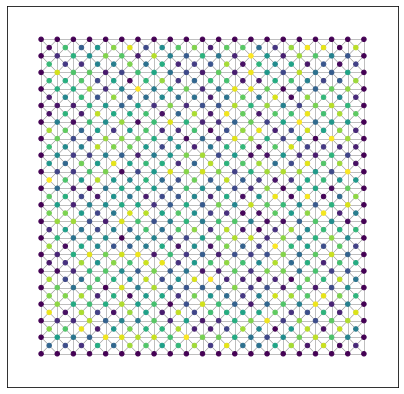

Layer (type:depth-idx)                   Output Shape              Param #
GNN                                      [36, 10]                  --
├─GATConv: 1-1                           [28800, 128]              384
│    └─Linear: 2-1                       [28800, 128]              1,024
│    └─SumAggregation: 2-2               [28800, 2, 64]            --
├─LayerNorm: 1-2                         [28800, 128]              256
├─ReLU: 1-3                              [28800, 128]              --
├─Dropout: 1-4                           [28800, 128]              --
├─ModuleList: 1-9                        --                        (recursive)
│    └─gatBlock: 2-3                     [28800, 128]              --
│    │    └─GATConv: 3-1                 [28800, 128]              16,768
│    │    └─LayerNorm: 3-2               [28800, 128]              256
│    │    └─ReLU: 3-3                    [28800, 128]              --
├─Dropout: 1-6                           [28800, 128]             

In [ ]:
GNN1 = MODEL(
    typ=DAT.model,
    model=GNN(in_size=DAT.UT_train_in.shape[-1], 
              h_size=[64, 64, 64, 64],
              out_size=DAT.UT_train_out.shape[-1], 
              act="relu",
              block="gat",
              norm="layer",
              dropout=0.2,
              bias=True,
              heads=2,
              pool="mean").to(device),
    lossf=nn.MSELoss(reduction="mean"),
    opt=("adam", 6.016e-6), #("adam", 1e-4),
    batch=36,
    lr=9e-4,
    data=DAT,
    mechMode=DAT.mechMode,
    scheduler=("min", 0.2427, 100, 1e-4), 
    earlyStop=EarlyStopping(patience=150, min_delta=1e-4, verbose=True),
    w_init="auto",
    device=device,
    optTrial=None,
    scan_matches_on_init=True
)

GNN1.summary()

In [ ]:
GNN1.train(n_epochs=1000, verbose=20, plot=True)

In [28]:
GNN1.save(path=None, name=None)

'models\\ut\\FCC_disNodes_dN-0.2_data-in_nSims-all_split-frac-0.9-seed-None-range-inTrue-outFalse_round-None_nodeFeat-geomTrue-coordNormTrue_scale-symm-inout-cfgHash4bd2f0_rDim-PCA-out-0.95-10--cfgHashdf4497\\gat\\date-20260506-194350_opt-Adam_lr-00009_batch-36_wd-0000006016_loss-MSELoss_earlyStop-patience150_wInit-Auto_sch-min-02427-100-00001_setupHash-e7a4c661.mdl'

In [ ]:
GNN1.predict(test_dataloader=None, plot=True)

In [ ]:
for i in range(len(GNN1.UT_test_outputs)):
    plot_predictions(DAT.UT_OUT_df, GNN1.UT_test_outputs, GNN1.UT_truth, indx=i, d_out=False)